# UC2 — DDoS Detection: XGBoost Training & Evaluation

**Goal:** Train a supervised XGBoost binary classifier on CICIDS2017 network flow
data to distinguish Benign traffic from DDoS attacks.

### Inputs (from `uc2_cicids2017_data_prep.ipynb`)

| File | Description |
|------|-------------|
| `uc2_train.csv` | Training set: Monday benign + Friday DDoS (70% temporal) |
| `uc2_test.csv` | Test set: Friday DDoS (30% temporal holdout) |
| `uc2_feature_cols.json` | Feature column names after correlation-based reduction |

### Pipeline

1. Load prepared CSVs and feature list
2. Exploratory sanity checks
3. **Carve a stratified validation slice from the training set** (15%,
   stratified on label to preserve class balance for early stopping)
4. Train XGBoost with class-imbalance handling (`scale_pos_weight`) and
   early stopping monitored on the validation slice
5. Test evaluation at a **fixed 0.5 probability threshold**
   (validation PR sweep retained as a sanity check, not as a tuning step)
6. Confusion matrix, classification report, ROC-AUC, PR-AUC
7. Feature importance analysis
8. False positive / false negative profiling
9. Model persistence (joblib artifact bundle)
10. Inference helper for Detection microservice

### Design Constraints

- **No circular labeling:** Labels come directly from CIC's ground truth annotations.
- **Temporal split:** The train/test boundary preserves time ordering
  (Friday afternoon 70/30, established in the data-prep notebook).
- **No test-set leakage:** Early stopping uses the stratified validation slice;
  the threshold is fixed at 0.5 and never tuned on the test set.
- **Threshold policy:** At CICIDS2017's saturation level (test AP ≈ 1.0),
  F1 is essentially flat across thresholds. We ship the standard 0.5 cutoff
  rather than fitting one to the test set.

In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score,
    roc_curve, roc_auc_score, f1_score, accuracy_score,
    precision_score, recall_score
)

import xgboost as xgb

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

print(f'XGBoost version: {xgb.__version__}')
print('Libraries loaded.')

XGBoost version: 3.2.0
Libraries loaded.


## 1. Configuration

In [2]:
# ── Paths ──
DATA_DIR  = './data/'
MODEL_DIR = './models/'
os.makedirs(MODEL_DIR, exist_ok=True)

TRAIN_CSV    = os.path.join(DATA_DIR, 'train.csv')
TEST_CSV     = os.path.join(DATA_DIR, 'test.csv')
FEAT_JSON    = os.path.join(DATA_DIR, 'flow_feature_cols.json')
ARTIFACT_OUT = os.path.join(MODEL_DIR, 'ddos_xgboost.pkl')

# ── Random seed ──
SEED = 42

print(f'Train CSV:  {TRAIN_CSV}')
print(f'Test CSV:   {TEST_CSV}')
print(f'Feature list: {FEAT_JSON}')
print(f'Artifact output: {ARTIFACT_OUT}')

Train CSV:  ./data/train.csv
Test CSV:   ./data/test.csv
Feature list: ./data/flow_feature_cols.json
Artifact output: ./models/ddos_xgboost.pkl


## 2. Load Prepared Data

In [3]:
with open(FEAT_JSON) as f:
    feature_cols = json.load(f)

df_train = pd.read_csv(TRAIN_CSV)
df_test  = pd.read_csv(TEST_CSV)

print(f'Feature columns: {len(feature_cols)}')
print(f'Train: {len(df_train):>10,} rows')
print(f'Test:  {len(df_test):>10,} rows')

# Verify all feature columns exist
for c in feature_cols:
    assert c in df_train.columns, f'Missing in train: {c}'
    assert c in df_test.columns,  f'Missing in test: {c}'
print('\nAll feature columns present in both splits.')

Feature columns: 45
Train:    686,440 rows
Test:      67,684 rows

All feature columns present in both splits.


## 3. Sanity Checks

In [4]:
# Label distribution
for name, df in [('Train', df_train), ('Test', df_test)]:
    print(f'\n── {name} ──')
    vc = df['label'].value_counts().sort_index()
    for lbl, cnt in vc.items():
        pct = 100 * cnt / len(df)
        tag = 'BENIGN' if lbl == 0 else 'DDoS'
        print(f'  {lbl} ({tag:8s})  {cnt:>10,}  ({pct:5.1f}%)')

# NaN / Inf check
for name, df in [('Train', df_train), ('Test', df_test)]:
    n_nan = df[feature_cols].isna().sum().sum()
    n_inf = np.isinf(df[feature_cols].select_dtypes(include=np.number)).sum().sum()
    print(f'\n{name}: NaN={n_nan}, Inf={n_inf}')
    assert n_nan == 0, f'{name} has NaN values'
    assert n_inf == 0, f'{name} has Inf values'

print('\nSanity checks passed.')


── Train ──
  0 (BENIGN  )     585,293  ( 85.3%)
  1 (DDoS    )     101,147  ( 14.7%)

── Test ──
  0 (BENIGN  )      40,804  ( 60.3%)
  1 (DDoS    )      26,880  ( 39.7%)

Train: NaN=0, Inf=0

Test: NaN=0, Inf=0

Sanity checks passed.


## 4. Prepare Feature Matrices

In [5]:
# Stratified validation carve-out from the training set.
#
# Why stratified rather than temporal-by-row-order:
#   The temporal no-leakage requirement is satisfied by the train/test
#   boundary itself (Friday 70/30, set in the data-prep notebook). Inside
#   uc2_train.csv the rows are class-clustered (Monday benign first, then
#   Friday DDoS), so a positional last-15% slice would be ~73% positive —
#   wrong prior for early-stopping logloss and for any threshold sweep.
#   Stratifying on label gives a val slice that mirrors the class prior
#   of the full training set.
val_frac = 0.15
df_tr, df_val = train_test_split(
    df_train,
    test_size=val_frac,
    stratify=df_train['label'],
    random_state=SEED,
)
df_tr  = df_tr.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)

X_tr,   y_tr   = df_tr[feature_cols].values,   df_tr['label'].values
X_val,  y_val  = df_val[feature_cols].values,  df_val['label'].values
X_test, y_test = df_test[feature_cols].values, df_test['label'].values

print(f'Train fold:  {X_tr.shape}   pos={y_tr.sum():>10,}   '
      f'neg={(y_tr==0).sum():>10,}   pos_rate={y_tr.mean():.3f}')
print(f'Validation:  {X_val.shape}  pos={y_val.sum():>10,}   '
      f'neg={(y_val==0).sum():>10,}   pos_rate={y_val.mean():.3f}')
print(f'Test:        {X_test.shape} pos={y_test.sum():>10,}   '
      f'neg={(y_test==0).sum():>10,}   pos_rate={y_test.mean():.3f}')

# scale_pos_weight derived from the training fold only (no leakage from val/test)
n_neg = (y_tr == 0).sum()
n_pos = (y_tr == 1).sum()
scale_pos_weight = n_neg / max(n_pos, 1)
print(f'\nscale_pos_weight (train fold only) = {scale_pos_weight:.2f}')

# Guardrails
assert y_val.sum() > 0,        'Validation slice has no positive (DDoS) examples.'
assert (y_val == 0).sum() > 0, 'Validation slice has no negative (Benign) examples.'

Train fold:  (583474, 45)   pos=    85,975   neg=   497,499   pos_rate=0.147
Validation:  (102966, 45)  pos=    15,172   neg=    87,794   pos_rate=0.147
Test:        (67684, 45) pos=    26,880   neg=    40,804   pos_rate=0.397

scale_pos_weight (train fold only) = 5.79


## 5. Feature Scaling

XGBoost is tree-based and does not strictly require scaling. However, we fit a
`StandardScaler` here for two reasons:

1. **Feature parity with UC4:** UC4 shares the same feature
   set and *does* need scaling. Persisting a shared scaler ensures consistency.
2. **Score interpretability:** Scaled features make feature importance magnitudes
   more comparable.

The scaler is fit on training data only — test data is transformed, never fit.

In [6]:
scaler = StandardScaler()
X_tr_scaled   = scaler.fit_transform(X_tr)
X_val_scaled  = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print('Scaler fitted on training fold only.')
print(f'  Train fold mean range: [{X_tr_scaled.mean(axis=0).min():.4f}, '
      f'{X_tr_scaled.mean(axis=0).max():.4f}]')
print(f'  Train fold std range:  [{X_tr_scaled.std(axis=0).min():.4f}, '
      f'{X_tr_scaled.std(axis=0).max():.4f}]')

Scaler fitted on training fold only.
  Train fold mean range: [-0.0000, 0.0000]
  Train fold std range:  [1.0000, 1.0000]


## 6. Train XGBoost

Hyperparameters are chosen as reasonable defaults for a binary classification
task with moderate dimensionality and potential class imbalance. The key parameter
is `scale_pos_weight` which compensates for the benign-heavy training set.

In [7]:
params = {
    'n_estimators':      300,
    'max_depth':         6,
    'learning_rate':     0.1,
    'subsample':         0.8,
    'colsample_bytree':  0.8,
    'min_child_weight':  5,
    'gamma':             0.1,
    'scale_pos_weight':  scale_pos_weight,
    'objective':         'binary:logistic',
    'eval_metric':       'logloss',
    'random_state':      SEED,
    'n_jobs':            -1,
    'early_stopping_rounds': 20,
}

print('XGBoost parameters:')
for k, v in params.items():
    print(f'  {k:25s}  {v}')

model = xgb.XGBClassifier(**params)

# eval_set: training fold (validation_0) + validation slice (validation_1).
# XGBoost's early stopping monitors the LAST entry in eval_set,
# so the validation slice — NOT the test set — drives the stopping criterion.
# The test set is never observed during training.
model.fit(
    X_tr_scaled, y_tr,
    eval_set=[(X_tr_scaled, y_tr), (X_val_scaled, y_val)],
    verbose=50,
)

print(f'\nTraining complete.  Best iteration: {model.best_iteration}')

XGBoost parameters:
  n_estimators               300
  max_depth                  6
  learning_rate              0.1
  subsample                  0.8
  colsample_bytree           0.8
  min_child_weight           5
  gamma                      0.1
  scale_pos_weight           5.7865542308810705
  objective                  binary:logistic
  eval_metric                logloss
  random_state               42
  n_jobs                     -1
  early_stopping_rounds      20
[0]	validation_0-logloss:0.59830	validation_1-logloss:0.59830
[50]	validation_0-logloss:0.00329	validation_1-logloss:0.00330
[100]	validation_0-logloss:0.00014	validation_1-logloss:0.00016
[150]	validation_0-logloss:0.00007	validation_1-logloss:0.00010
[200]	validation_0-logloss:0.00005	validation_1-logloss:0.00010

Training complete.  Best iteration: 180


## 7. Training Curves

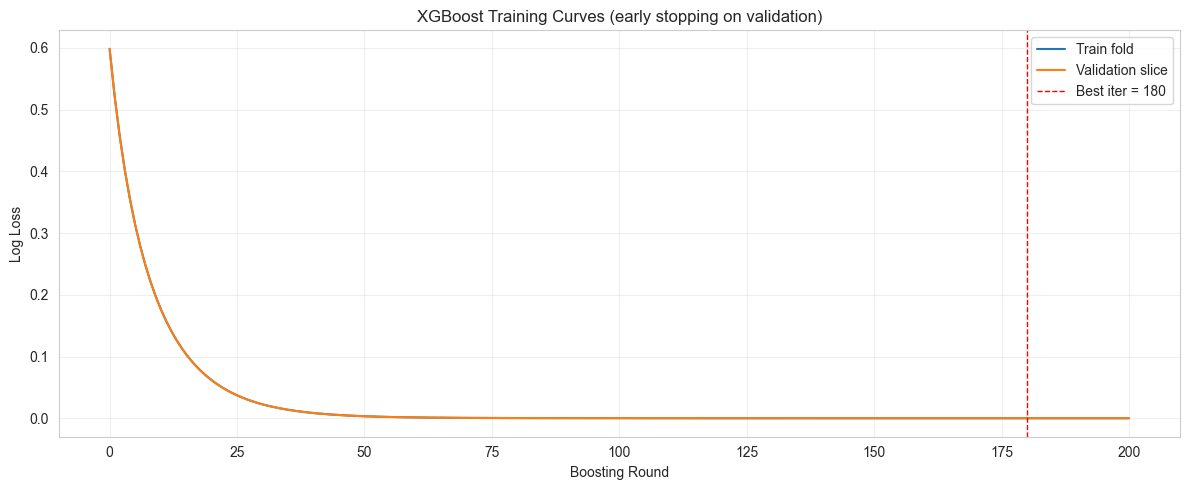

Best validation logloss: 0.000095 at round 180


In [8]:
results = model.evals_result()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(results['validation_0']['logloss'], label='Train fold', linewidth=1.5)
ax.plot(results['validation_1']['logloss'], label='Validation slice', linewidth=1.5)
ax.axvline(model.best_iteration, color='red', linestyle='--', linewidth=1,
           label=f'Best iter = {model.best_iteration}')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('Log Loss')
ax.set_title('XGBoost Training Curves (early stopping on validation)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_round = model.best_iteration
print(f'Best validation logloss: '
      f'{results["validation_1"]["logloss"][best_round]:.6f} '
      f'at round {best_round}')

## 8. Test Evaluation at Default Threshold (0.5)

Reported as a baseline. The optimized threshold (selected on the
**validation slice**, not on this test set) is reported in Section 12.

In [9]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]
y_pred_default = (y_prob >= 0.5).astype(int)

print('── Classification Report (threshold=0.5) ──\n')
print(classification_report(y_test, y_pred_default,
                            target_names=['Benign', 'DDoS'], digits=4))

acc = accuracy_score(y_test, y_pred_default)
print(f'Accuracy: {acc:.4f}')

── Classification Report (threshold=0.5) ──

              precision    recall  f1-score   support

      Benign     0.9993    1.0000    0.9996     40804
        DDoS     1.0000    0.9989    0.9994     26880

    accuracy                         0.9995     67684
   macro avg     0.9996    0.9994    0.9995     67684
weighted avg     0.9995    0.9995    0.9995     67684

Accuracy: 0.9995


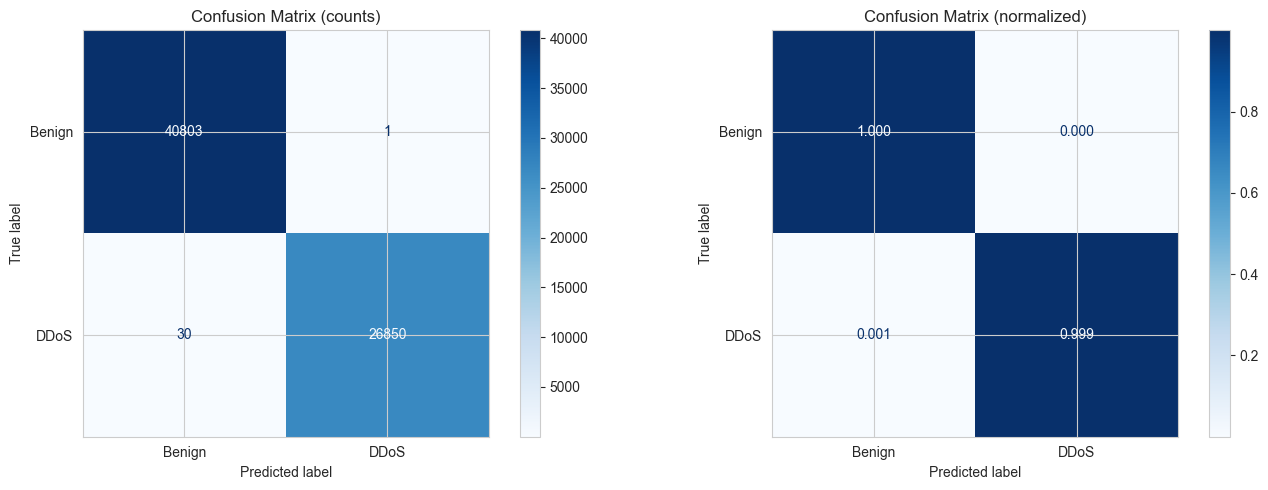

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_default,
    display_labels=['Benign', 'DDoS'],
    cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix (counts)')

# Normalized
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_default,
    display_labels=['Benign', 'DDoS'],
    normalize='true', cmap='Blues', ax=axes[1],
    values_format='.3f')
axes[1].set_title('Confusion Matrix (normalized)')

plt.tight_layout()
plt.show()

## 9. Score Distribution Analysis

How well does the model's predicted probability separate the two classes?

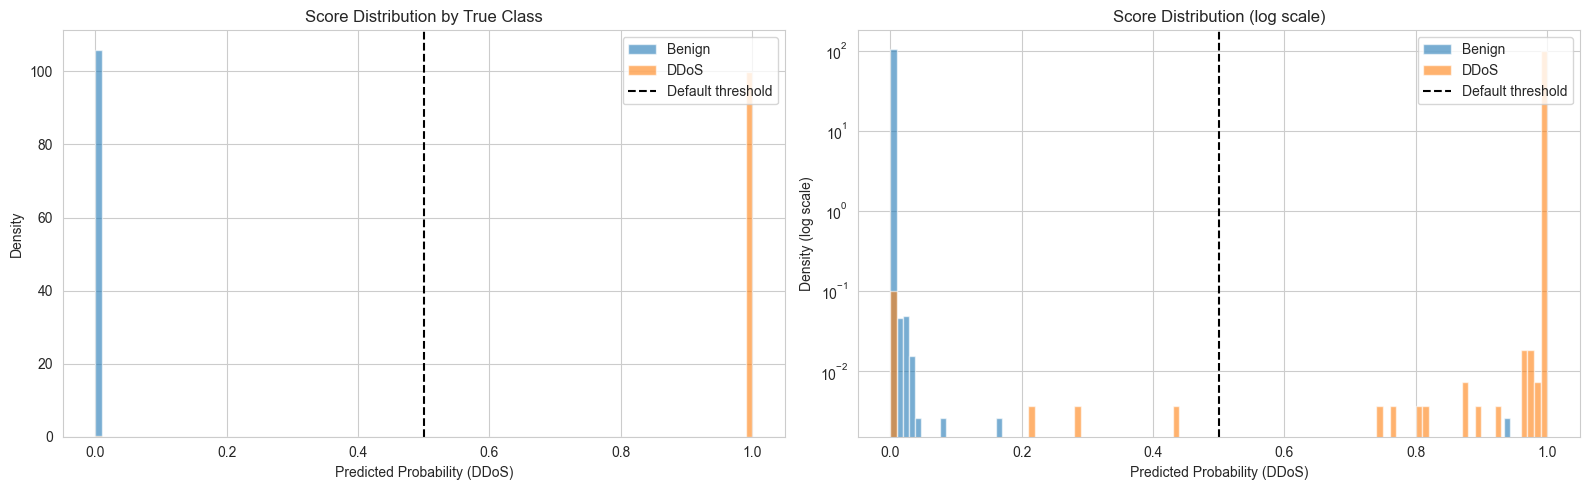

Benign  prob  — median: 0.000004,  P95: 0.000123,  max: 0.942982
DDoS    prob  — median: 0.999994,  P5:  0.999975,  min: 0.000016


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram
ax = axes[0]
ax.hist(y_prob[y_test == 0], bins=100, alpha=0.6, label='Benign', density=True)
ax.hist(y_prob[y_test == 1], bins=100, alpha=0.6, label='DDoS', density=True)
ax.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Default threshold')
ax.set_xlabel('Predicted Probability (DDoS)')
ax.set_ylabel('Density')
ax.set_title('Score Distribution by True Class')
ax.legend()

# Log-scale for better tail visibility
ax2 = axes[1]
ax2.hist(y_prob[y_test == 0], bins=100, alpha=0.6, label='Benign', density=True)
ax2.hist(y_prob[y_test == 1], bins=100, alpha=0.6, label='DDoS', density=True)
ax2.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Default threshold')
ax2.set_xlabel('Predicted Probability (DDoS)')
ax2.set_ylabel('Density (log scale)')
ax2.set_yscale('log')
ax2.set_title('Score Distribution (log scale)')
ax2.legend()

plt.tight_layout()
plt.show()

# Separation quality metrics
benign_probs = y_prob[y_test == 0]
ddos_probs   = y_prob[y_test == 1]
print(f'Benign  prob  — median: {np.median(benign_probs):.6f},  '
      f'P95: {np.percentile(benign_probs, 95):.6f},  '
      f'max: {benign_probs.max():.6f}')
print(f'DDoS    prob  — median: {np.median(ddos_probs):.6f},  '
      f'P5:  {np.percentile(ddos_probs, 5):.6f},  '
      f'min: {ddos_probs.min():.6f}')

## 10. Threshold Policy and Validation Sanity Check

The probability threshold is **fixed at 0.5** — the standard cutoff for a
binary classifier. We do not tune it on the test set (circular) nor on the
validation slice (unnecessary at this AP saturation level, and a small
amount of additional moving parts in the artifact).

The validation PR curve below is plotted as a sanity check: it confirms the
0.5 cutoff sits on a flat region of the F1 curve, and lets us inspect how
class separation looks on data the model never trained on. The test PR
curve is plotted in parallel for reporting.

── Threshold policy ──
Selected threshold:     0.5000  (fixed, not tuned)
Validation AP:          1.0000
Validation F1 @ 0.5:    0.9999
Validation max F1:      0.9999  (reference only)

── Test reporting at threshold = 0.5 ──
Test AP:              0.9999
Test Precision @ 0.5: 1.0000
Test Recall    @ 0.5: 0.9989


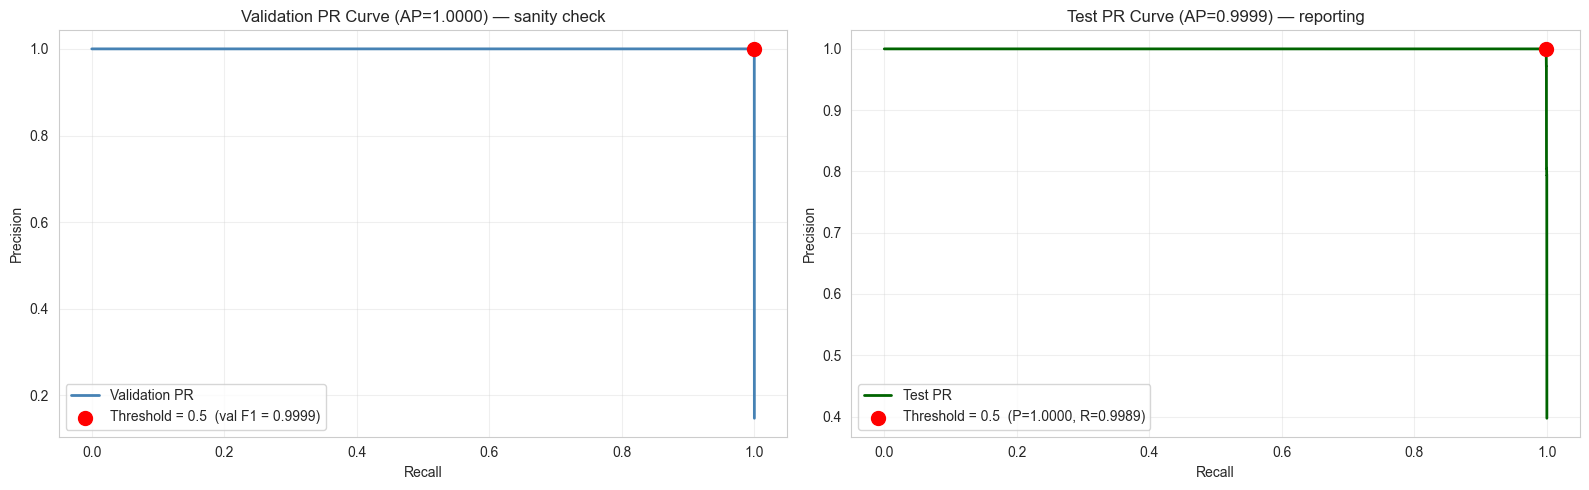

In [12]:
# ── Threshold policy: fixed at 0.5 ──
# At CICIDS2017's saturation level F1 is essentially flat across thresholds;
# tuning yields no meaningful gain and risks looking like test-set fitting.
best_threshold = 0.5

# ── Validation PR curve — sanity check only ──
val_prob = model.predict_proba(X_val_scaled)[:, 1]
val_p, val_r, val_thr = precision_recall_curve(y_val, val_prob)
val_f1 = 2 * (val_p[:-1] * val_r[:-1]) / (val_p[:-1] + val_r[:-1] + 1e-10)
val_ap = average_precision_score(y_val, val_prob)
val_f1_at_05_idx = int(np.argmin(np.abs(val_thr - 0.5)))
val_f1_at_05 = float(val_f1[val_f1_at_05_idx])
val_best_f1 = float(val_f1.max())   # for reference only, NOT used for selection

print(f'── Threshold policy ──')
print(f'Selected threshold:     {best_threshold:.4f}  (fixed, not tuned)')
print(f'Validation AP:          {val_ap:.4f}')
print(f'Validation F1 @ 0.5:    {val_f1_at_05:.4f}')
print(f'Validation max F1:      {val_best_f1:.4f}  (reference only)')

# ── Test PR curve — for reporting ──
precision_arr, recall_arr, thresholds_pr = precision_recall_curve(y_test, y_prob)
ap_score = average_precision_score(y_test, y_prob)
f1_arr = 2 * (precision_arr[:-1] * recall_arr[:-1]) / (
    precision_arr[:-1] + recall_arr[:-1] + 1e-10)
test_thr_idx = int(np.argmin(np.abs(thresholds_pr - best_threshold)))
test_p_at_sel = precision_arr[test_thr_idx]
test_r_at_sel = recall_arr[test_thr_idx]

print(f'\n── Test reporting at threshold = 0.5 ──')
print(f'Test AP:              {ap_score:.4f}')
print(f'Test Precision @ 0.5: {test_p_at_sel:.4f}')
print(f'Test Recall    @ 0.5: {test_r_at_sel:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Validation PR — sanity check
ax = axes[0]
ax.plot(val_r, val_p, linewidth=2, color='steelblue', label='Validation PR')
ax.scatter(val_r[val_f1_at_05_idx], val_p[val_f1_at_05_idx],
           color='red', s=100, zorder=5,
           label=f'Threshold = 0.5  (val F1 = {val_f1_at_05:.4f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title(f'Validation PR Curve (AP={val_ap:.4f}) — sanity check')
ax.legend(); ax.grid(True, alpha=0.3)

# Test PR — reporting
ax2 = axes[1]
ax2.plot(recall_arr, precision_arr, linewidth=2, color='darkgreen', label='Test PR')
ax2.scatter(test_r_at_sel, test_p_at_sel,
            color='red', s=100, zorder=5,
            label=f'Threshold = 0.5  (P={test_p_at_sel:.4f}, R={test_r_at_sel:.4f})')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title(f'Test PR Curve (AP={ap_score:.4f}) — reporting')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. ROC Curve

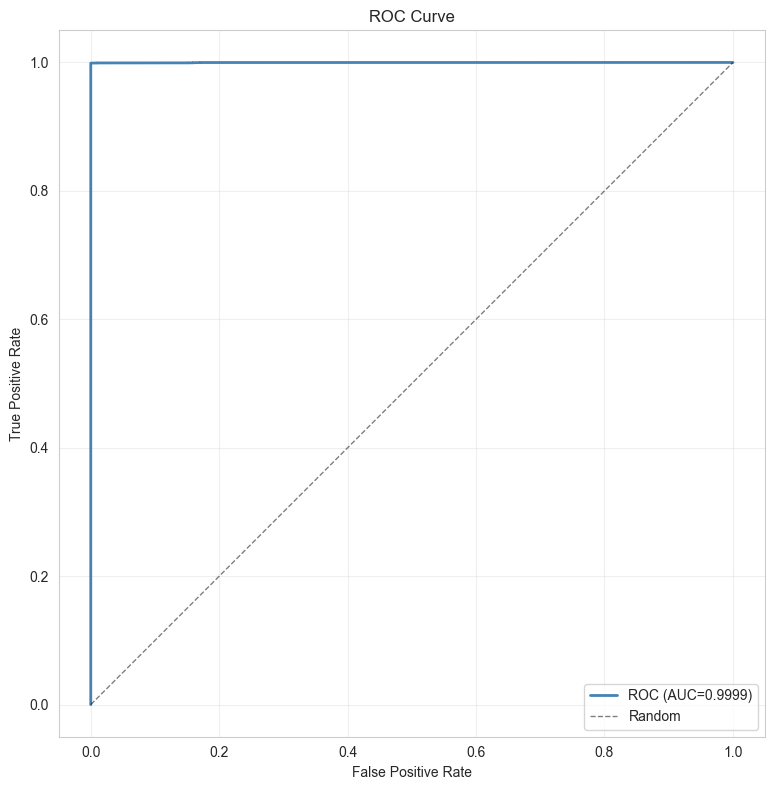

ROC-AUC: 0.9999


In [13]:
fpr_arr, tpr_arr, thresholds_roc = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(fpr_arr, tpr_arr, linewidth=2, color='steelblue',
        label=f'ROC (AUC={roc_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

print(f'ROC-AUC: {roc_auc:.4f}')

## 12. Test Evaluation at Fixed Threshold (0.5)

The same threshold used in Section 8 — repeated here so the rest of the
notebook (error analysis, operational sweep, artifact bundle) all reference
a single canonical `best_threshold` variable.

In [14]:
y_pred_opt = (y_prob >= best_threshold).astype(int)

print(f'── Classification Report (threshold={best_threshold:.4f}) ──\n')
print(classification_report(y_test, y_pred_opt,
                            target_names=['Benign', 'DDoS'], digits=4))

# Side-by-side comparison
print('\n── Default vs Optimized Threshold ──')
print(f'{"Metric":20s}  {"Default (0.5)":>14s}  {"Optimized":>14s}')
print('-' * 52)
for metric_name, metric_fn in [
    ('Accuracy',  accuracy_score),
    ('Precision', lambda y, p: precision_score(y, p, zero_division=0)),
    ('Recall',    lambda y, p: recall_score(y, p, zero_division=0)),
    ('F1',        lambda y, p: f1_score(y, p, zero_division=0)),
]:
    v_def = metric_fn(y_test, y_pred_default)
    v_opt = metric_fn(y_test, y_pred_opt)
    delta = v_opt - v_def
    sign  = '+' if delta >= 0 else ''
    print(f'{metric_name:20s}  {v_def:>14.4f}  {v_opt:>14.4f}  ({sign}{delta:.4f})')

── Classification Report (threshold=0.5000) ──

              precision    recall  f1-score   support

      Benign     0.9993    1.0000    0.9996     40804
        DDoS     1.0000    0.9989    0.9994     26880

    accuracy                         0.9995     67684
   macro avg     0.9996    0.9994    0.9995     67684
weighted avg     0.9995    0.9995    0.9995     67684


── Default vs Optimized Threshold ──
Metric                 Default (0.5)       Optimized
----------------------------------------------------
Accuracy                      0.9995          0.9995  (+0.0000)
Precision                     1.0000          1.0000  (+0.0000)
Recall                        0.9989          0.9989  (+0.0000)
F1                            0.9994          0.9994  (+0.0000)


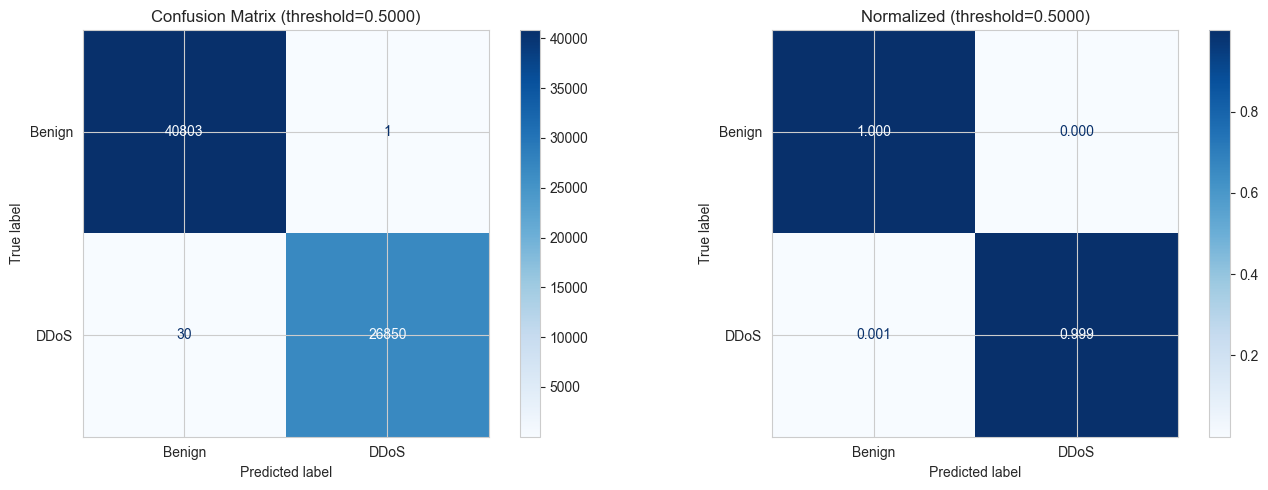

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_opt,
    display_labels=['Benign', 'DDoS'],
    cmap='Blues', ax=axes[0])
axes[0].set_title(f'Confusion Matrix (threshold={best_threshold:.4f})')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_opt,
    display_labels=['Benign', 'DDoS'],
    normalize='true', cmap='Blues', ax=axes[1],
    values_format='.3f')
axes[1].set_title(f'Normalized (threshold={best_threshold:.4f})')

plt.tight_layout()
plt.show()

## 13. Feature Importance

Three importance perspectives:
- **Weight (frequency):** How often a feature is used in splits.
- **Gain:** Average gain when the feature is used in a split.
- **Cover:** Average number of samples affected by splits on the feature.

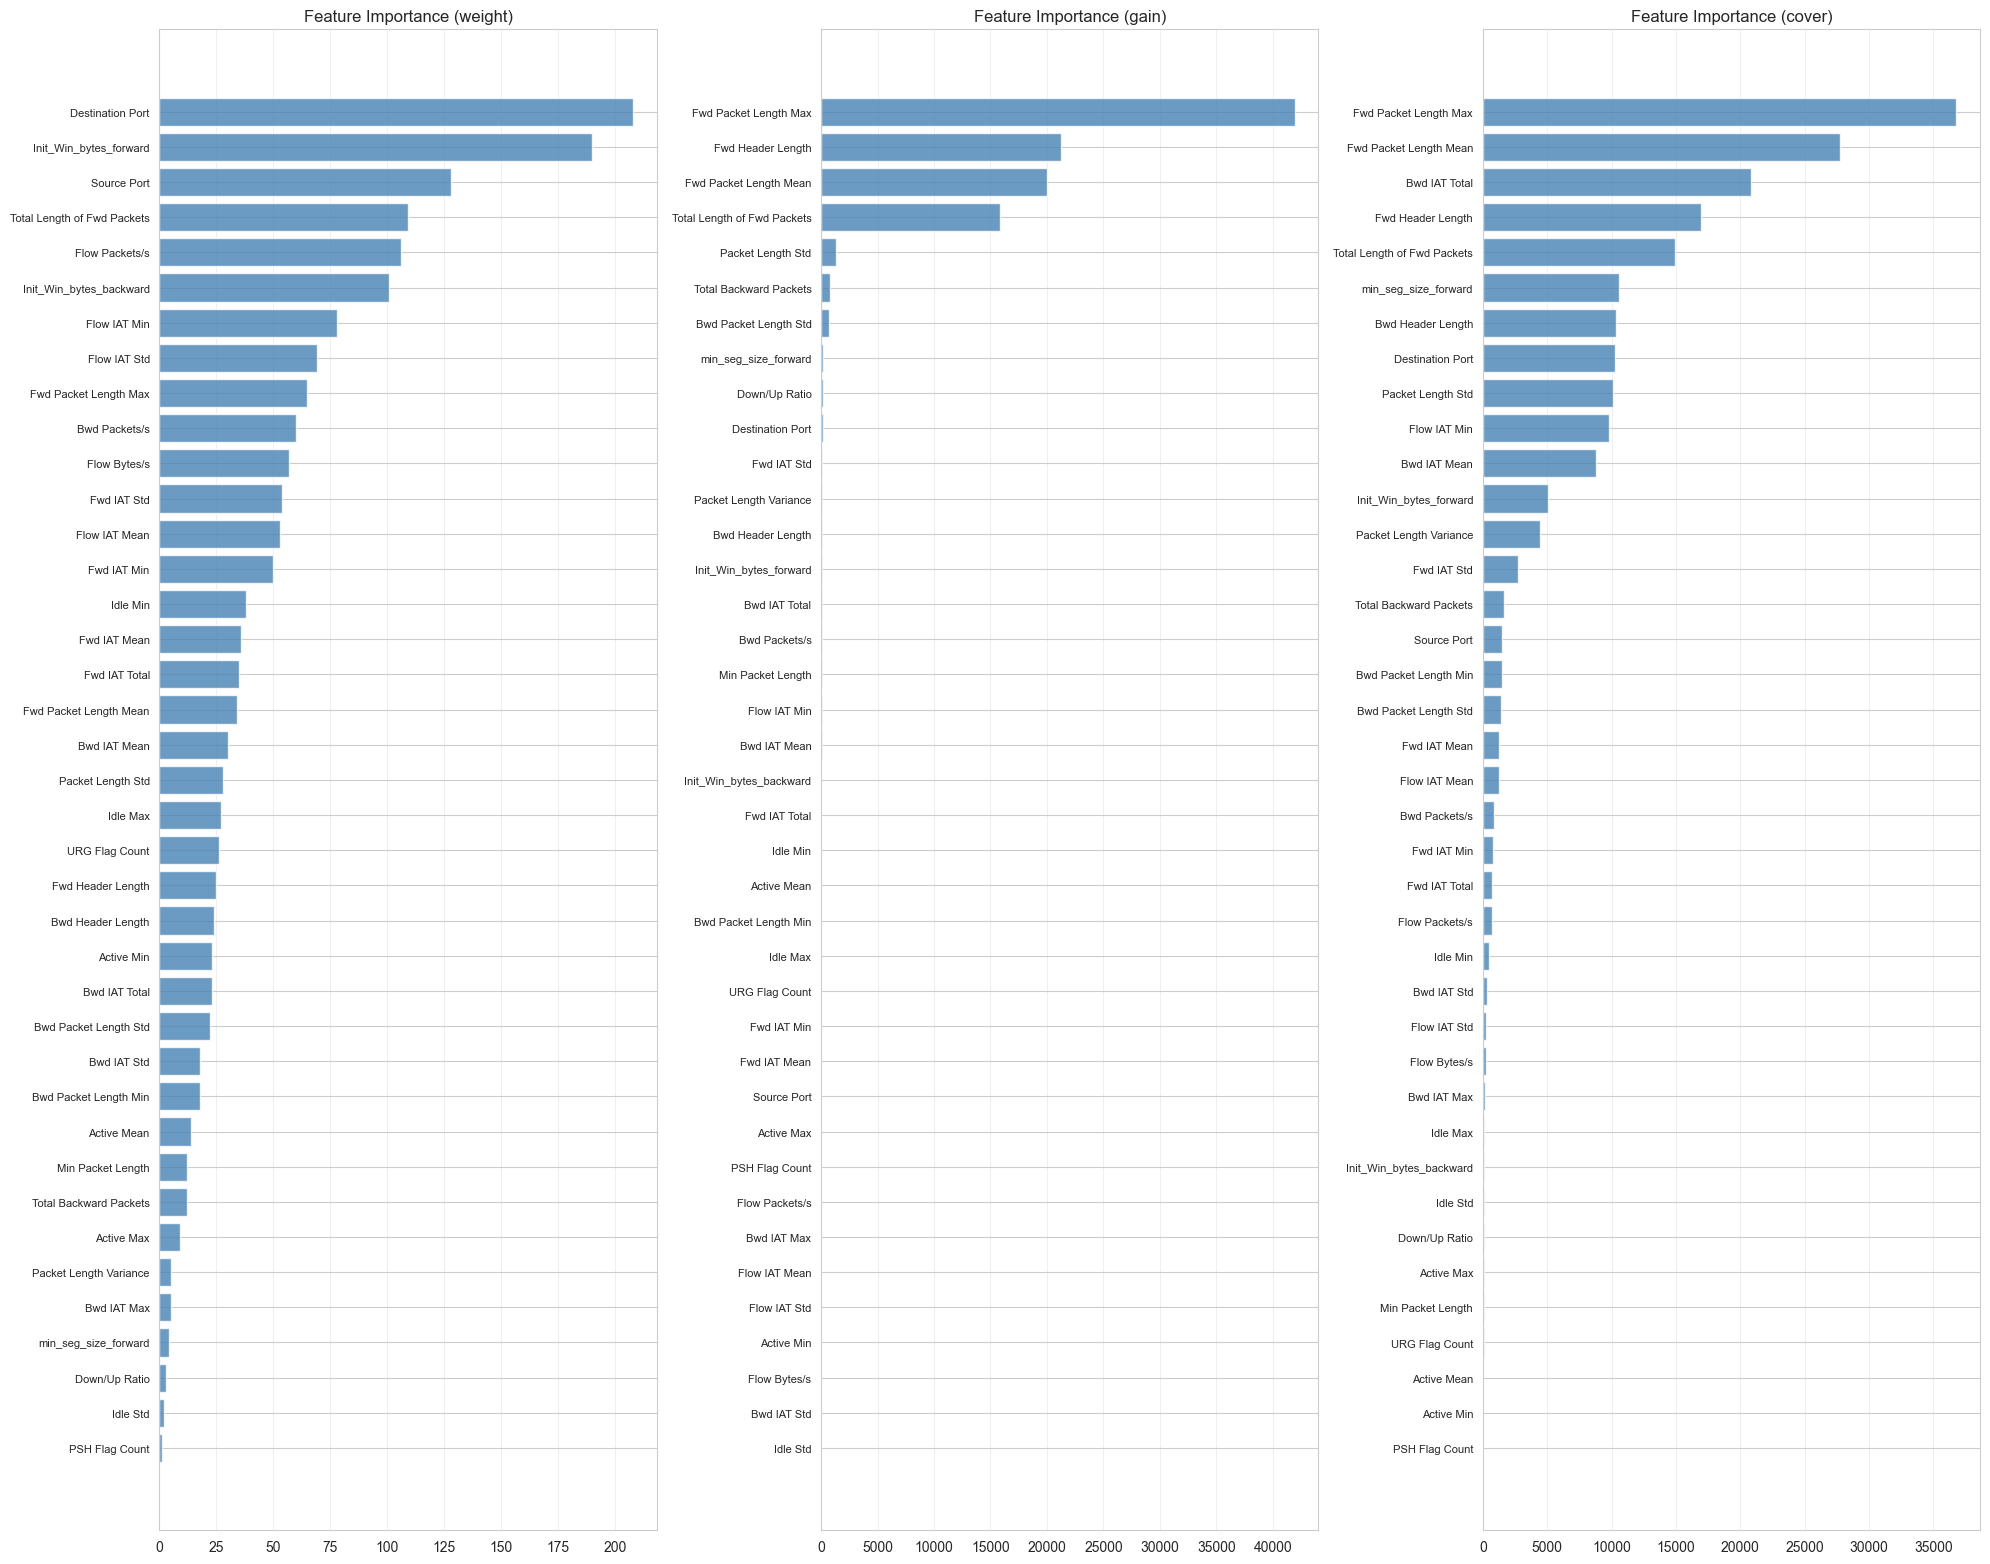

In [16]:
importance_types = ['weight', 'gain', 'cover']
importances = {}

for imp_type in importance_types:
    imp = model.get_booster().get_score(importance_type=imp_type)
    # XGBoost uses f0, f1, ... as feature names when trained on arrays
    imp_named = {}
    for k, v in imp.items():
        idx = int(k.replace('f', ''))
        imp_named[feature_cols[idx]] = v
    importances[imp_type] = imp_named

fig, axes = plt.subplots(1, 3, figsize=(20, max(8, len(feature_cols) * 0.35)))

for i, imp_type in enumerate(importance_types):
    ax = axes[i]
    imp = importances[imp_type]
    # Sort by value
    sorted_imp = sorted(imp.items(), key=lambda x: x[1])
    names = [x[0] for x in sorted_imp]
    vals  = [x[1] for x in sorted_imp]

    ax.barh(range(len(names)), vals, color='steelblue', alpha=0.8)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=8)
    ax.set_title(f'Feature Importance ({imp_type})')
    ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

In [17]:
# Combined importance table sorted by gain
imp_df = pd.DataFrame({
    'feature': feature_cols,
    'weight': [importances['weight'].get(c, 0) for c in feature_cols],
    'gain':   [importances['gain'].get(c, 0)   for c in feature_cols],
    'cover':  [importances['cover'].get(c, 0)  for c in feature_cols],
})

# Normalize each column to [0, 1] for ranking
for col in ['weight', 'gain', 'cover']:
    mx = imp_df[col].max()
    imp_df[f'{col}_norm'] = imp_df[col] / mx if mx > 0 else 0

imp_df['combined_score'] = (imp_df['weight_norm'] +
                             imp_df['gain_norm'] +
                             imp_df['cover_norm']) / 3
imp_df = imp_df.sort_values('combined_score', ascending=False)

print('Feature Importance Ranking:')
print(f'{"Rank":>4s}  {"Feature":45s}  {"Weight":>8s}  {"Gain":>10s}  '
      f'{"Cover":>10s}  {"Combined":>8s}')
print('-' * 95)
for rank, (_, row) in enumerate(imp_df.iterrows(), 1):
    print(f'{rank:4d}  {row["feature"]:45s}  {row["weight"]:8.0f}  '
          f'{row["gain"]:10.2f}  {row["cover"]:10.2f}  {row["combined_score"]:8.4f}')

Feature Importance Ranking:
Rank  Feature                                          Weight        Gain       Cover  Combined
-----------------------------------------------------------------------------------------------
   1  Fwd Packet Length Max                                65    41943.06    36785.38    0.7708
   2  Fwd Packet Length Mean                               34    20008.38    27716.24    0.4647
   3  Total Length of Fwd Packets                         109    15886.29    14954.68    0.4364
   4  Destination Port                                    208      131.33    10241.62    0.4272
   5  Fwd Header Length                                    25    21225.06    16967.70    0.3625
   6  Init_Win_bytes_forward                              190       77.69     5059.15    0.3509
   7  Bwd IAT Total                                        23       73.50    20848.78    0.2264
   8  Source Port                                         128       10.03     1528.48    0.2191
   9  Flow I

## 14. Error Analysis

### 14.1 False Positives

Benign flows incorrectly classified as DDoS. Understanding these helps set
operational thresholds and informs whether additional features or post-processing
rules are needed.

In [18]:
fp_mask = (y_test == 0) & (y_pred_opt == 1)
fn_mask = (y_test == 1) & (y_pred_opt == 0)

n_fp = fp_mask.sum()
n_fn = fn_mask.sum()
print(f'False Positives: {n_fp:,}  (benign classified as DDoS)')
print(f'False Negatives: {n_fn:,}  (DDoS classified as benign)')

if n_fp > 0:
    fp_df = df_test[fp_mask].copy()
    fp_df['prob'] = y_prob[fp_mask]
    print(f'\n── False Positive Profile ──')
    print(f'Probability range: [{fp_df["prob"].min():.4f}, {fp_df["prob"].max():.4f}]')
    print(f'Probability median: {fp_df["prob"].median():.4f}')
    print(f'\nFeature statistics (FP vs all benign):')
    benign_all = df_test[y_test == 0]
    stats = []
    for c in feature_cols:
        stats.append({
            'feature': c,
            'fp_mean': fp_df[c].mean(),
            'fp_std':  fp_df[c].std(),
            'benign_mean': benign_all[c].mean(),
            'benign_std':  benign_all[c].std(),
        })
    stats_df = pd.DataFrame(stats)
    # Show features where FP mean deviates most from benign mean
    stats_df['deviation'] = (
        (stats_df['fp_mean'] - stats_df['benign_mean']).abs() /
        (stats_df['benign_std'] + 1e-10)
    )
    stats_df = stats_df.sort_values('deviation', ascending=False)
    print(stats_df.head(10).to_string(index=False))
else:
    print('\nNo false positives — perfect precision on benign class.')

False Positives: 1  (benign classified as DDoS)
False Negatives: 30  (DDoS classified as benign)

── False Positive Profile ──
Probability range: [0.9430, 0.9430]
Probability median: 0.9430

Feature statistics (FP vs all benign):
              feature   fp_mean  fp_std  benign_mean    benign_std  deviation
        Bwd Packets/s  500000.0     NaN  4370.405745  30287.988166  16.363899
       Flow Packets/s 1000000.0     NaN 39011.611215 187537.625614   5.124243
       ACK Flag Count       1.0     NaN     0.358617      0.479600   1.337329
          Source Port   10695.0     NaN 34436.812126  26944.945613   0.881123
             Protocol       6.0     NaN    10.235443      5.359486   0.790270
 min_seg_size_forward      20.0     NaN    23.675032      5.777421   0.636102
     Destination Port      80.0     NaN 15866.753014  24881.890121   0.634468
       PSH Flag Count       0.0     NaN     0.252426      0.434410   0.581079
Bwd Packet Length Min       6.0     NaN    43.330801     69.012767  

### 14.2 False Negatives

DDoS flows that escaped detection. These are the most dangerous errors.

In [19]:
if n_fn > 0:
    fn_df = df_test[fn_mask].copy()
    fn_df['prob'] = y_prob[fn_mask]
    print(f'── False Negative Profile ──')
    print(f'Probability range: [{fn_df["prob"].min():.4f}, {fn_df["prob"].max():.4f}]')
    print(f'Probability median: {fn_df["prob"].median():.4f}')

    # How close were they to the threshold?
    near_threshold = (fn_df['prob'] >= best_threshold - 0.1).sum()
    print(f'\nFN within 0.1 of threshold: {near_threshold}/{n_fn} '
          f'({100*near_threshold/n_fn:.1f}%)')

    print(f'\nFeature statistics (FN vs all DDoS):')
    ddos_all = df_test[y_test == 1]
    stats = []
    for c in feature_cols:
        stats.append({
            'feature': c,
            'fn_mean': fn_df[c].mean(),
            'fn_std':  fn_df[c].std(),
            'ddos_mean': ddos_all[c].mean(),
            'ddos_std':  ddos_all[c].std(),
        })
    stats_df = pd.DataFrame(stats)
    stats_df['deviation'] = (
        (stats_df['fn_mean'] - stats_df['ddos_mean']).abs() /
        (stats_df['ddos_std'] + 1e-10)
    )
    stats_df = stats_df.sort_values('deviation', ascending=False)
    print(stats_df.head(10).to_string(index=False))
else:
    print('No false negatives — perfect recall on DDoS class.')

── False Negative Profile ──
Probability range: [0.0000, 0.4363]
Probability median: 0.0000

FN within 0.1 of threshold: 1/30 (3.3%)

Feature statistics (FN vs all DDoS):
                    feature       fn_mean       fn_std    ddos_mean      ddos_std  deviation
             FIN Flag Count      0.900000 3.051286e-01     0.001004      0.031678  28.379218
Total Length of Fwd Packets     13.600000 3.124983e+00    30.258631     10.047860   1.657928
               Flow IAT Min 407880.033333 1.304535e+06  4556.172173 273621.471314   1.474021
                Fwd IAT Min 407880.033333 1.304535e+06  4687.980357 273621.101607   1.473542
          Fwd Header Length     46.400000 9.312950e+00    92.866369     32.502848   1.429609
    Init_Win_bytes_backward     -1.000000 0.000000e+00   126.321429    114.340145   1.113532
                Source Port  63259.000000 6.614636e+03 51151.291853  10881.747377   1.112662
      Fwd Packet Length Max      6.000000 0.000000e+00    13.732292      6.961720   1

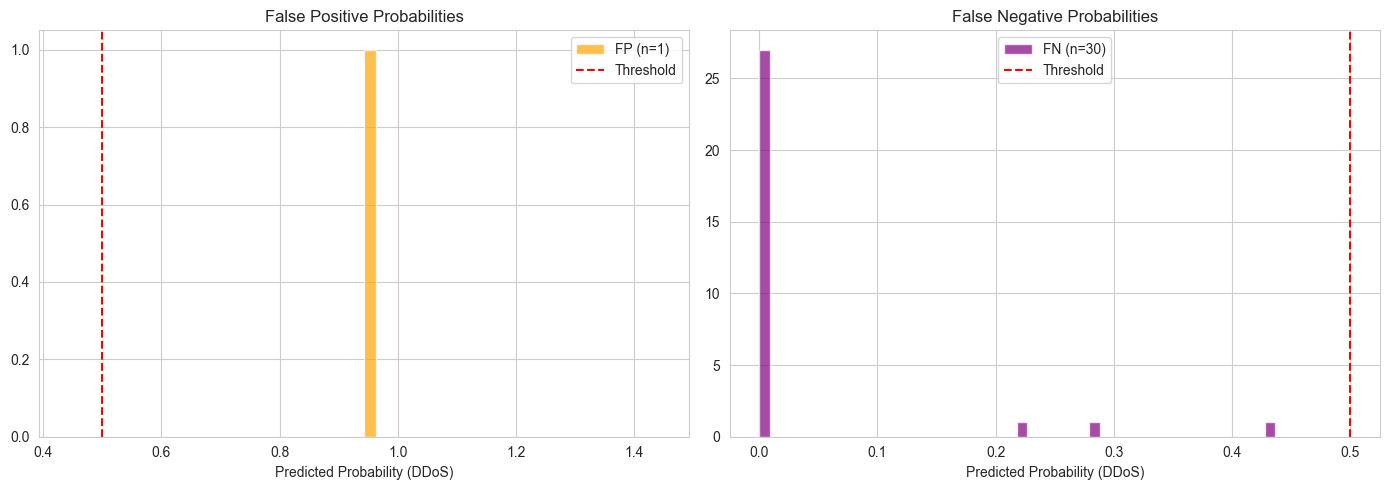

In [20]:
if n_fp + n_fn > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # FP probability distribution
    ax = axes[0]
    if n_fp > 0:
        ax.hist(y_prob[fp_mask], bins=50, alpha=0.7, color='orange',
                label=f'FP (n={n_fp})')
    ax.axvline(best_threshold, color='red', linestyle='--', label='Threshold')
    ax.set_xlabel('Predicted Probability (DDoS)')
    ax.set_title('False Positive Probabilities')
    ax.legend()

    # FN probability distribution
    ax2 = axes[1]
    if n_fn > 0:
        ax2.hist(y_prob[fn_mask], bins=50, alpha=0.7, color='purple',
                 label=f'FN (n={n_fn})')
    ax2.axvline(best_threshold, color='red', linestyle='--', label='Threshold')
    ax2.set_xlabel('Predicted Probability (DDoS)')
    ax2.set_title('False Negative Probabilities')
    ax2.legend()

    plt.tight_layout()
    plt.show()
else:
    print('No errors to visualize.')

## 15. Operational Threshold Selection

In a DDoS detection system, the cost of a false negative (missed attack) is
typically higher than a false positive (flagged benign traffic). We present
metrics at several threshold levels so the operator can choose based on their
risk tolerance.

In [21]:
print(f'{"Threshold":>10s}  {"Precision":>10s}  {"Recall":>10s}  '
      f'{"F1":>10s}  {"FPR":>10s}  {"FP":>8s}  {"FN":>8s}')
print('-' * 70)

for t in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    y_t = (y_prob >= t).astype(int)
    p = precision_score(y_test, y_t, zero_division=0)
    r = recall_score(y_test, y_t, zero_division=0)
    f = f1_score(y_test, y_t, zero_division=0)
    fp_count = ((y_test == 0) & (y_t == 1)).sum()
    fn_count = ((y_test == 1) & (y_t == 0)).sum()
    fpr_default  = fp_count / max((y_test == 0).sum(), 1)
    marker = '  : Selected policy' if abs(t - best_threshold) < 1e-6 else ''
    print(f'{t:10.4f}  {p:10.4f}  {r:10.4f}  {f:10.4f}  '
          f'{fpr_default:10.6f}  {fp_count:8,}  {fn_count:8,}{marker}')

 Threshold   Precision      Recall          F1         FPR        FP        FN
----------------------------------------------------------------------
    0.3000      1.0000      0.9989      0.9994    0.000025         1        29
    0.4000      1.0000      0.9989      0.9994    0.000025         1        29
    0.5000      1.0000      0.9989      0.9994    0.000025         1        30  : Selected policy
    0.6000      1.0000      0.9989      0.9994    0.000025         1        30
    0.7000      1.0000      0.9989      0.9994    0.000025         1        30
    0.8000      1.0000      0.9988      0.9994    0.000025         1        32
    0.9000      1.0000      0.9986      0.9993    0.000025         1        37


## 16. Model Persistence

Save as a single artifact bundle containing the model, scaler, threshold, feature
list, and metadata. The Detection microservice loads this single file.

In [22]:
artifact = {
    'model':        model,
    'scaler':       scaler,
    'threshold':    float(best_threshold),
    'feature_cols': feature_cols,
    'params':       params,
    'metrics': {
        # Threshold provenance: fixed at 0.5, not tuned
        'threshold':              float(best_threshold),
        'threshold_source':       'fixed_0.5',
        # Validation reporting
        'val_size':               int(len(y_val)),
        'val_ap':                 float(val_ap),
        'val_f1_at_threshold':    float(val_f1_at_05),
        # Test reporting
        'test_size':              int(len(y_test)),
        'test_roc_auc':           float(roc_auc),
        'test_ap':                float(ap_score),
        'test_f1_at_threshold':   float(f1_score(y_test, y_pred_opt)),
        'test_precision_at_threshold': float(precision_score(y_test, y_pred_opt)),
        'test_recall_at_threshold':    float(recall_score(y_test, y_pred_opt)),
        # Training fold size and best iteration
        'train_size':             int(len(y_tr)),
        'best_iteration':         int(model.best_iteration),
    },
    'label_map': {0: 'BENIGN', 1: 'DDoS'},
}

joblib.dump(artifact, ARTIFACT_OUT, compress=3)
size_mb = os.path.getsize(ARTIFACT_OUT) / (1024 * 1024)
print(f'Artifact saved: {ARTIFACT_OUT}  ({size_mb:.1f} MB)')
print(f'Contents: {list(artifact.keys())}')

Artifact saved: ./models/ddos_xgboost.pkl  (0.1 MB)
Contents: ['model', 'scaler', 'threshold', 'feature_cols', 'params', 'metrics', 'label_map']


## 17. Artifact Verification

Reload the saved artifact and verify predictions match.

In [23]:
art = joblib.load(ARTIFACT_OUT)

# Re-predict using loaded artifact
X_verify   = art['scaler'].transform(df_test[art['feature_cols']].values)
probs_verify = art['model'].predict_proba(X_verify)[:, 1]
preds_verify = (probs_verify >= art['threshold']).astype(int)

assert np.allclose(probs_verify, y_prob, atol=1e-6), 'Probability mismatch!'
assert np.array_equal(preds_verify, y_pred_opt), 'Prediction mismatch!'

print('Artifact verification passed.')
print(f'  Model type:               {type(art["model"]).__name__}')
print(f'  Features:                 {len(art["feature_cols"])}')
print(f'  Threshold:                {art["threshold"]:.4f}  '
      f'(source: {art["metrics"]["threshold_source"]})')
print(f'  Best iteration:           {art["metrics"]["best_iteration"]}')
print(f'  Val   F1 @ threshold:     {art["metrics"]["val_f1_at_threshold"]:.4f}')
print(f'  Test  F1 @ threshold:     {art["metrics"]["test_f1_at_threshold"]:.4f}')
print(f'  Test  ROC-AUC:            {art["metrics"]["test_roc_auc"]:.4f}')
print(f'  Test  AP:                 {art["metrics"]["test_ap"]:.4f}')

Artifact verification passed.
  Model type:               XGBClassifier
  Features:                 45
  Threshold:                0.5000  (source: fixed_0.5)
  Best iteration:           180
  Val   F1 @ threshold:     0.9999
  Test  F1 @ threshold:     0.9994
  Test  ROC-AUC:            0.9999
  Test  AP:                 0.9999


## 18. Inference Helper

Reusable function for the Detection microservice. Loads the artifact bundle and
predicts on new flow data.

```python
# In the Detection FastAPI service:
from uc2_inference import predict_uc2
result = predict_uc2(flow_features_df)
```

In [24]:
def predict_uc2(df: pd.DataFrame, artifact_path: str = None) -> dict:
    """
    Run UC2 XGBoost inference on a DataFrame of flow features.

    Parameters
    ----------
    df : pd.DataFrame
        Flow feature data. Must contain all columns from uc2_feature_cols.json.
    artifact_path : str, optional
        Path to the saved .joblib artifact.

    Returns
    -------
    dict with keys:
        'predictions': np.ndarray of 0/1
        'probabilities': np.ndarray of float
        'threshold': float used for classification
    """
    if artifact_path is None:
        artifact_path = ARTIFACT_OUT

    art = joblib.load(artifact_path)
    X = art['scaler'].transform(df[art['feature_cols']].values)
    probs = art['model'].predict_proba(X)[:, 1]
    preds = (probs >= art['threshold']).astype(int)

    return {
        'predictions':   preds,
        'probabilities': probs,
        'threshold':     art['threshold'],
    }


# Sanity check
result = predict_uc2(df_test)
assert np.array_equal(result['predictions'], y_pred_opt), 'Sanity check failed!'
print('Inference helper verified — predictions match training notebook.')

Inference helper verified — predictions match training notebook.


## 19. Summary

In [25]:
print('=' * 70)
print('UC2 XGBOOST TRAINING SUMMARY')
print('=' * 70)
print(f'Dataset:          CICIDS2017 (Monday benign + Friday DDoS)')
print(f'Model:            XGBoost binary classifier')
print(f'Features:         {len(feature_cols)}')
print(f'Train fold:       {len(y_tr):>10,}  (pos_rate={y_tr.mean():.3f})')
print(f'Validation slice: {len(y_val):>10,}  (stratified, used for early stopping)')
print(f'Test:             {len(y_test):>10,}  (pos_rate={y_test.mean():.3f})')
print(f'Best iteration:   {model.best_iteration} of {params["n_estimators"]}')
print(f'')
print(f'── Threshold policy ──')
print(f'Fixed at 0.5  (not tuned on test or validation)')
print(f'  Validation F1 @ 0.5:  {val_f1_at_05:.4f}')
print(f'')
print(f'── Test performance @ threshold = 0.5 ──')
print(f'ROC-AUC:          {roc_auc:.4f}')
print(f'Average Precision:{ap_score:.4f}')
print(f'F1 Score:         {f1_score(y_test, y_pred_opt):.4f}')
print(f'Precision:        {precision_score(y_test, y_pred_opt):.4f}')
print(f'Recall:           {recall_score(y_test, y_pred_opt):.4f}')
print(f'False Positives:  {n_fp:,}')
print(f'False Negatives:  {n_fn:,}')
print(f'')
print(f'── Artifact ──')
print(f'Path:             {ARTIFACT_OUT}')
print(f'Contents:         model, scaler, threshold, feature_cols, params, metrics')
print('=' * 70)

UC2 XGBOOST TRAINING SUMMARY
Dataset:          CICIDS2017 (Monday benign + Friday DDoS)
Model:            XGBoost binary classifier
Features:         45
Train fold:          583,474  (pos_rate=0.147)
Validation slice:    102,966  (stratified, used for early stopping)
Test:                 67,684  (pos_rate=0.397)
Best iteration:   180 of 300

── Threshold policy ──
Fixed at 0.5  (not tuned on test or validation)
  Validation F1 @ 0.5:  0.9999

── Test performance @ threshold = 0.5 ──
ROC-AUC:          0.9999
Average Precision:0.9999
F1 Score:         0.9994
Precision:        1.0000
Recall:           0.9989
False Positives:  1
False Negatives:  30

── Artifact ──
Path:             ./models/ddos_xgboost.pkl
Contents:         model, scaler, threshold, feature_cols, params, metrics
